# EDA 


In [1]:
#Import all the libraries

import pandas as pd
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

In [5]:
#Import the Finalised dataset from step 1
df = pd.read_csv("Datasets/Finalized_Dataset.csv", sep=",", header=0)
print(df.head(5)) # Display the head

                                             content  temperature_2m_mean  \
0  Collision between a car and a motorbike in Żur...             0.103670   
1  Car-motorcycle traffic accident Yesterday, at ...             0.697599   
2  Car-motorcycle collision in Ħal Qormi Today, a...            -0.044812   
3  Collision between motorcycle and car in Għaxaq...             0.827521   
4  Car-motorcycle collision Yesterday, at around ...            -1.047068   

   apparent_temperature_mean  precipitation_sum  precipitation_hours  \
0                   0.148919          -0.204187            -0.579751   
1                   0.877228          -0.154628             0.151526   
2                  -0.007147          -0.204187            -0.579751   
3                   0.734167          -0.204187            -0.579751   
4                  -1.021578           0.060125             0.395285   

   wind_speed_10m_max  is_holiday  year  month  day  tag_National  \
0           -1.258551           0  

## Univariate Analysis

In [ ]:
#Analyze the variables Mean, Median, Variance and Standard Deviation - Basic Univariate Analysis

stats_df = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Variance': df.var(numeric_only=True),
    'Standard Deviation': df.std(numeric_only=True)
})

pd.options.display.float_format = '{:.4f}'.format
display(stats_df)

,Mean,Median,Variance,Standard Deviation
temperature_2m_mean,0.0000,0.0651,1.0023,1.0012
apparent_temperature_mean,-0.0000,0.0034,1.0023,1.0012
precipitation_sum,-0.0000,-0.2042,1.0023,1.0012
precipitation_hours,0.0000,-0.5586,1.0023,1.0012
wind_speed_10m_max,-0.0000,-0.1775,1.0023,1.0012
is_holiday,0.0370,0.0000,0.0357,0.1891
year,2024.9097,2025.0000,0.0823,0.2869
month,6.3773,7.0000,10.4861,3.2382
day,15.4329,15.5000,67.6939,8.2276
tag_National,0.7407,1.0000,0.1925,0.4387


### A Quick Look

- For the following variables: 
    - `temperature_2m_mean`,
    - `apparent_temperature_mean`,
    - `precipitation_sum`,
    - `precipitation_hours`,
    - `wind_speed_10m_max`

The mean hovers at $0$ with Variance and Standard Deviation hovering at 1, showing that these values have been standarised properly for training.

The `is_holiday`feature is a weak standalone predictor but from the mean we can tell that around $3.7$% of the rows are holidays.

The `year` feature is almost a constant feature due to the low variance and might have a low predictive value.

The `month` feature shows a good seasonal spread.

The `day` feature is a cyclic feature with a quite a uniform distribution. **It might be better to divide the days in days of the week instead as this would yield a stronger signal**. 

The following table, interpreatates the tags and their mean to show how common the tags occur in the articles.
<center>

| Feature       | Mean | Interpretation |
| ------------- | ---- | -------------- |
| tag_National  | 0.74 | Very frequent  |
| tag_Accident  | 0.77 | Very frequent  |
| tag_Traffic   | 0.57 | Moderate       |
| tag_Police    | 0.42 | Balanced       |
| tag_Transport | 0.07 | Rare           |

</center>


## Continuous Values

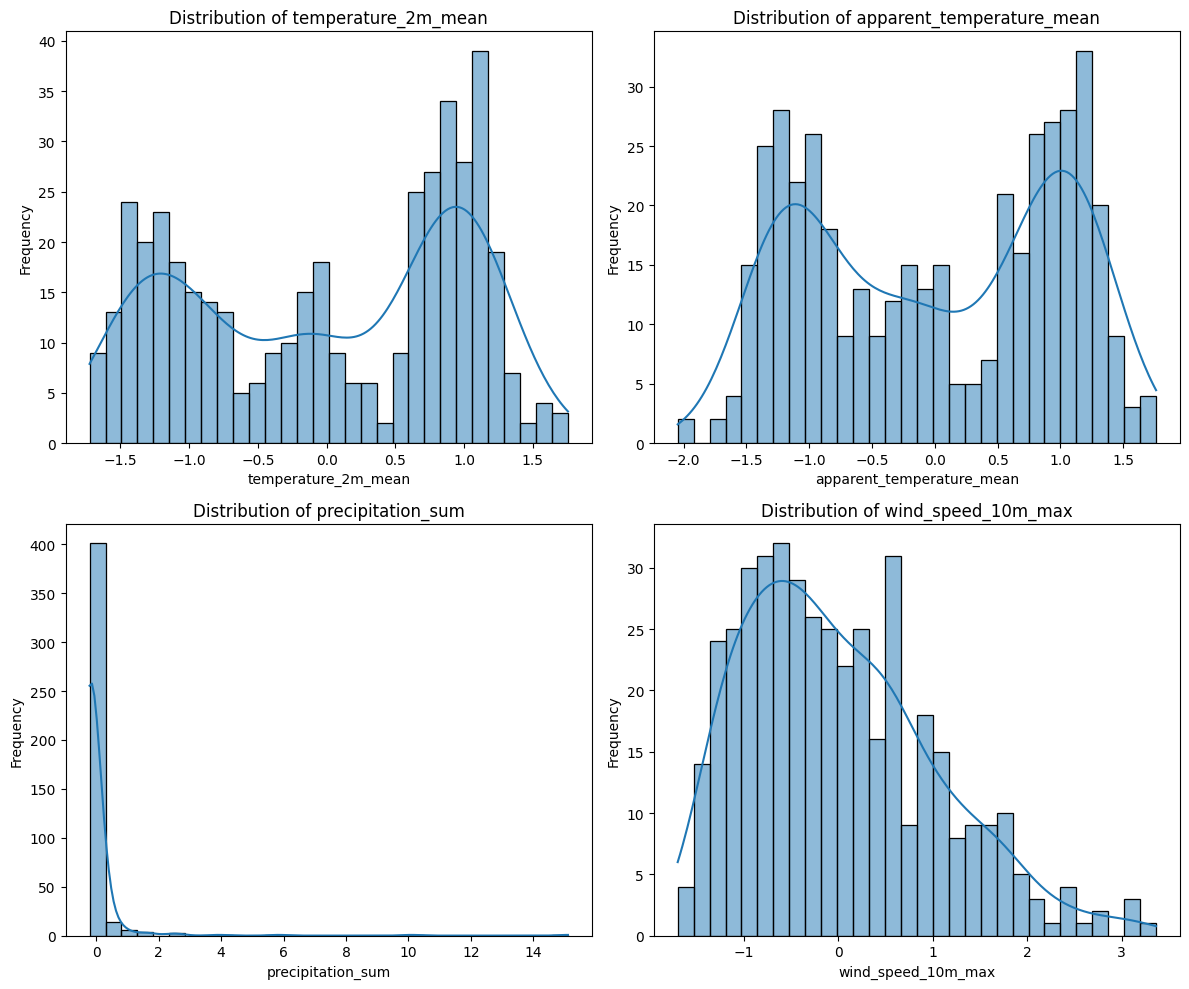

In [13]:

## Continues Columns Histogram Plot

continuous_cols = [
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "precipitation_sum",
    "wind_speed_10m_max"
]

# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Flatten the axes array from 2x2 to a 1D list of 4 for easy looping
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    # Select the specific subplot for this column
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

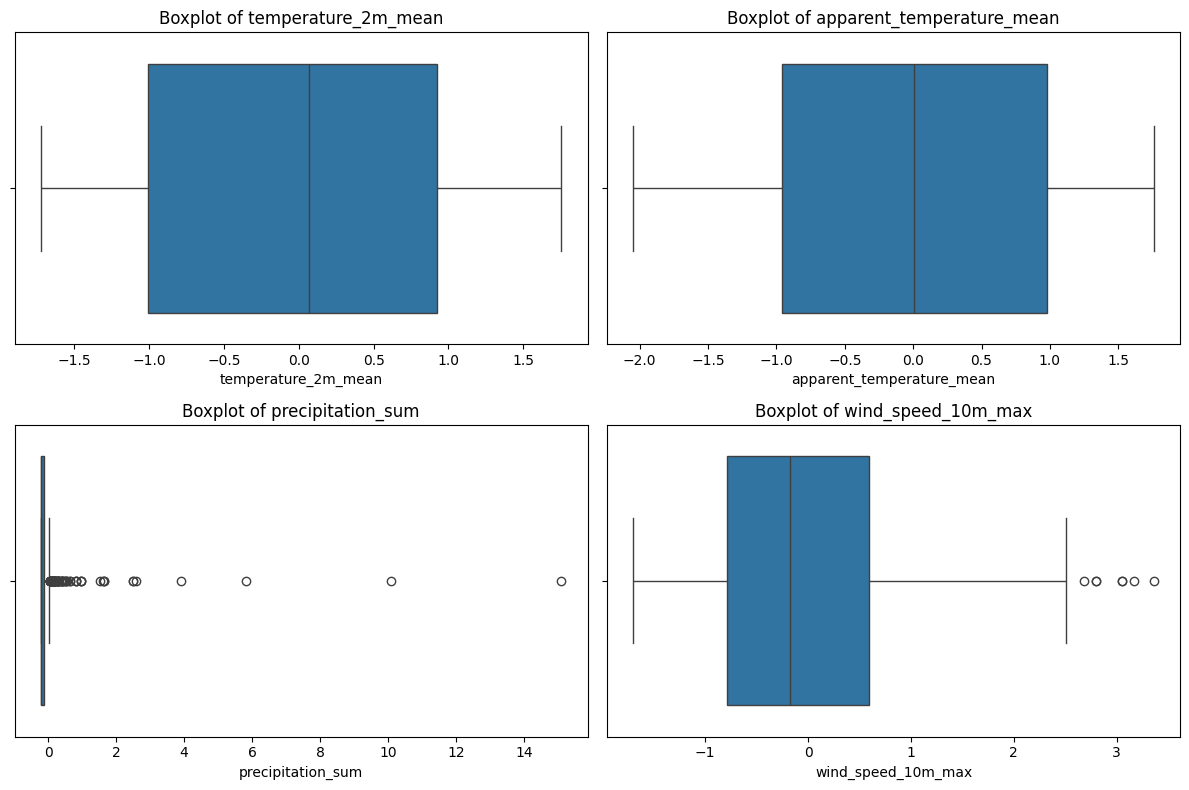

In [14]:
# 1. Initialize the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 2. Flatten the axes so we can iterate through them easily (0, 1, 2, 3)
axes = axes.flatten()

# 3. Loop through your columns and assign each to an axis
for i, col in enumerate(continuous_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    
    # Use axes[i] to set titles and labels for each specific subplot
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

# 4. Cleanup: Adjust spacing and display
plt.tight_layout()
plt.show()

## Continuous Anylsis 

The histograms for `temperature_2m_mean` & `apparent_temperature_mean` shows a binomial distribution  with no visible outliers which means that linear models might struggle to find a single weight for temprature. To combact this for linear models it might be better to create a category feature **Day vs Night**.

Tree-Based Models and Clustering models can handle the binomial distribution better and should be able to use the temperature value as is.

The `precipitation_sum` and `wind_speed_10m_max` histogram and boxplot show that the data is extremely right-skewed, dominated by zero-values and a long tail of significant high-end outliers. It shows that on most of the days there are no to little rain but there are a number of outliers which signify days with stormy weather. This means that this feature might require log-transformation for non-tree-based-models.

**Conclusion:** The temperature features are well-distributed for most ML algorithms, the high skewness and outlier density in the precipitation and wind features suggest that tree-based models or targeted feature engineering will be essential to handle the non-normal variance and extreme values effectively.

## Discrete Columns


Value counts for precipitation_hours
precipitation_hours
-0.5798     66
-0.5586    208
-0.3360      6
-0.2689     12
-0.0922      4
0.0208       8
0.1515       8
0.3104      18
0.3953       8
0.6001      23
0.6390       2
0.8828       2
0.8898      14
1.1266       2
1.1795       6
1.4692       7
1.6141       3
1.8578       2
2.0485       4
2.1016       2
2.3382       7
2.3454       1
2.6279       5
2.8329       4
2.9175       2
3.2072       1
3.4969       4
3.7866       1
4.5392       1
5.5247       1
Name: count, dtype: int64

Value counts for year
year
2024     39
2025    393
Name: count, dtype: int64

Value counts for month
month
1     40
2     40
3     19
4     32
5     34
6     32
7     50
8     74
9     42
10    30
12    39
Name: count, dtype: int64

Value counts for day
day
1     13
2      7
3     15
4     12
5     15
6     12
7     26
8      9
9     17
10    11
11    13
12    17
13    12
14    22
15    15
16    20
17    20
18    12
19    13
20    17
21    12
22    17
23    14


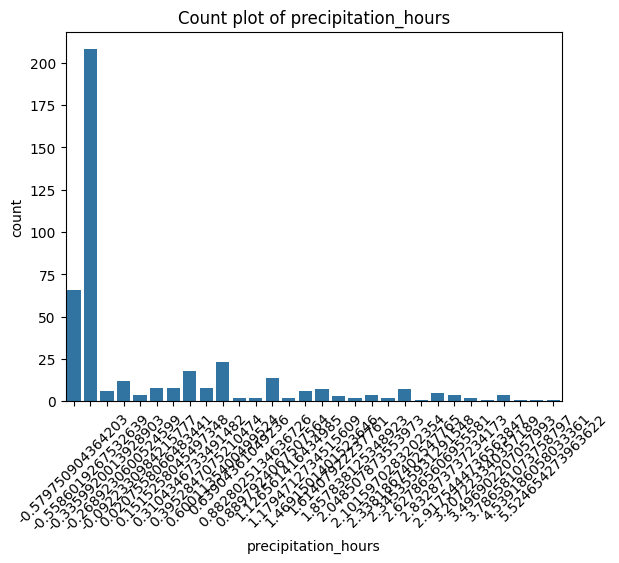

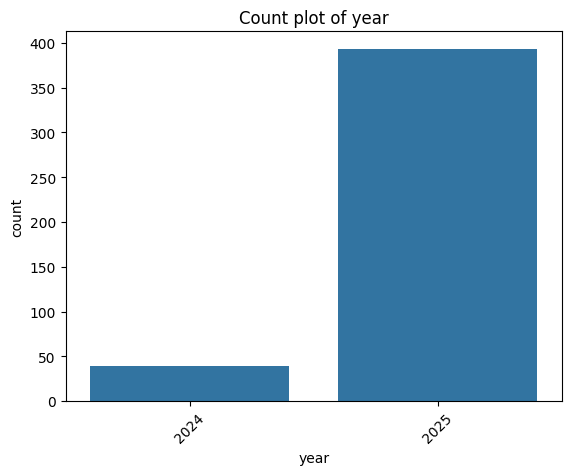

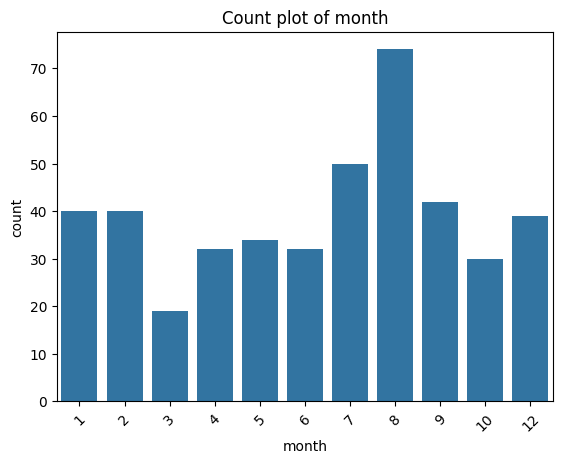

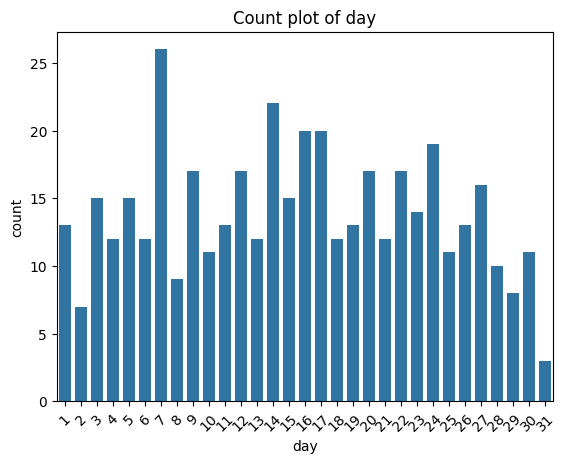

In [7]:
discrete_cols = [
    "precipitation_hours",
    "year",
    "month",
    "day"
]

for col in discrete_cols:
    print(f"\nValue counts for {col}")
    print(df[col].value_counts().sort_index())

for col in discrete_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f"Count plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [8]:
binary_cols = [
    "is_holiday",
    "tag_National",
    "tag_Accident",
    "tag_Traffic",
    "tag_Police",
    "tag_Transport"
]

binary_summary = pd.DataFrame({
    "count": df[binary_cols].sum(),
    "percentage": df[binary_cols].mean() * 100
})

binary_summary

,count,percentage
is_holiday,16,3.7037
tag_National,320,74.0741
tag_Accident,333,77.0833
tag_Traffic,247,57.1759
tag_Police,180,41.6667
tag_Transport,32,7.4074


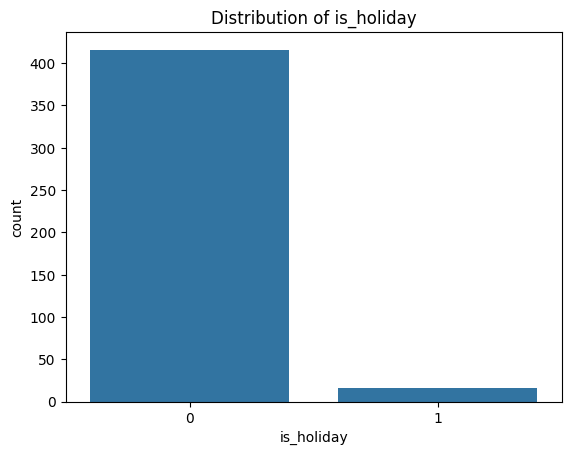

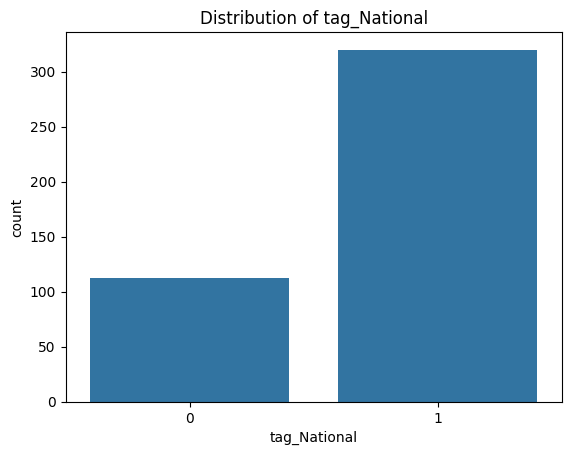

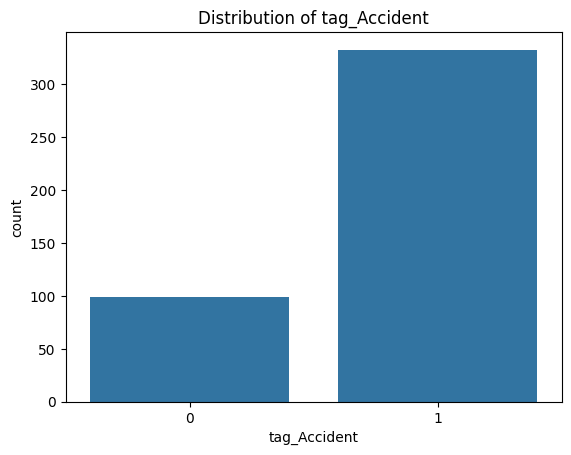

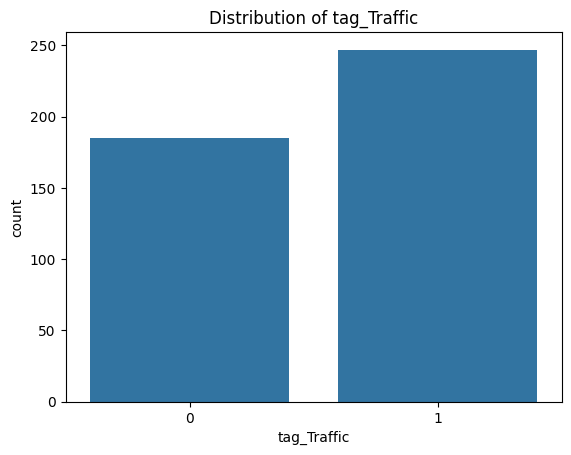

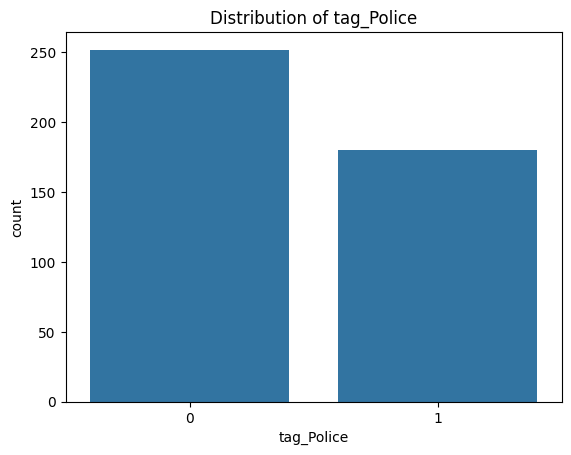

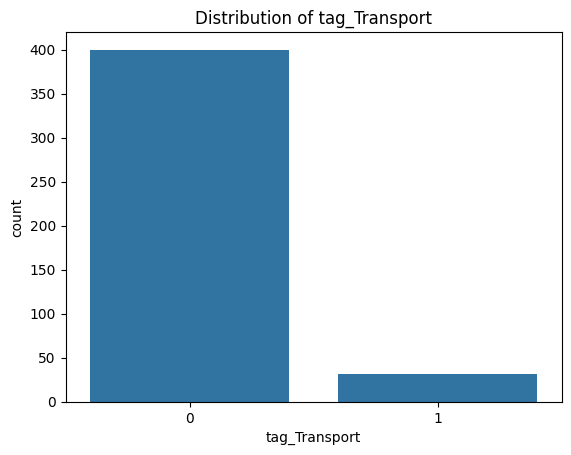

In [9]:
for col in binary_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()


In [10]:
zero_summary = {
    col: (df[col] == 0).mean() * 100
    for col in ["precipitation_sum", "precipitation_hours"]
}

pd.Series(zero_summary, name="Zero Percentage")

precipitation_sum     0.0000
precipitation_hours   0.0000
Name: Zero Percentage, dtype: float64

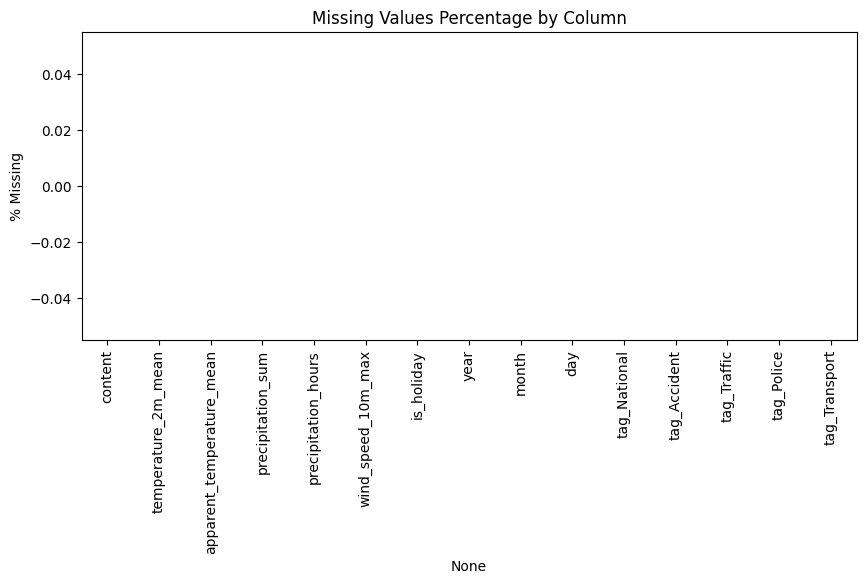

In [13]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

plt.figure(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=90)
plt.title("Missing Values Percentage by Column")
plt.ylabel("% Missing")
plt.show()

In [14]:
df[continuous_cols].agg(["skew", "kurtosis"]).T

,skew,kurtosis
temperature_2m_mean,-0.1969,-1.4644
apparent_temperature_mean,-0.0802,-1.4673
precipitation_sum,11.1585,146.9349
wind_speed_10m_max,0.7328,0.1481


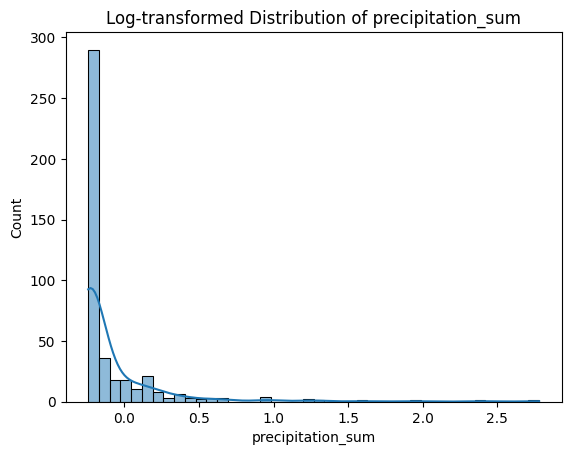

c:\Users\peljo\anaconda3\envs\ICS\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


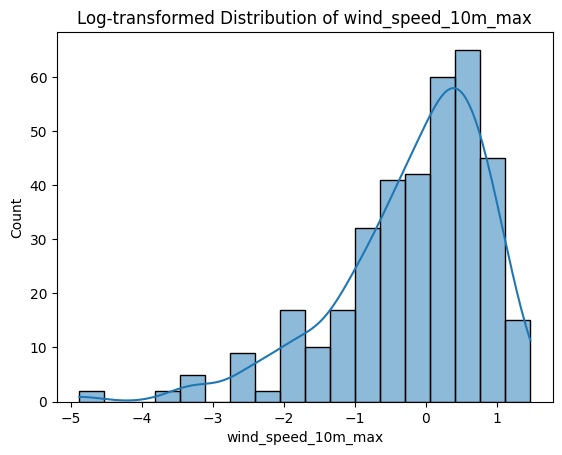

In [15]:
for col in ["precipitation_sum", "wind_speed_10m_max"]:
    plt.figure()
    sns.histplot(np.log1p(df[col]), kde=True)
    plt.title(f"Log-transformed Distribution of {col}")
    plt.show()

In [16]:
def univariate_summary(df):
    summary = []

    for col in df.columns:
        summary.append({
            "column": col,
            "dtype": df[col].dtype,
            "missing_%": df[col].isna().mean() * 100,
            "unique": df[col].nunique(),
            "mean": df[col].mean() if pd.api.types.is_numeric_dtype(df[col]) else None,
            "std": df[col].std() if pd.api.types.is_numeric_dtype(df[col]) else None,
            "min": df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else None,
            "max": df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else None
        })

    return pd.DataFrame(summary)

univariate_summary(df)

,column,dtype,missing_%,unique,mean,std,min,max
0,content,object,0.0000,432,NaN,NaN,NaN,NaN
1,temperature_2m_mean,float64,0.0000,175,0.0000,1.0012,-1.7237,1.7555
2,apparent_temperature_mean,float64,0.0000,206,-0.0000,1.0012,-2.0466,1.7616
3,precipitation_sum,float64,0.0000,55,-0.0000,1.0012,-0.2157,15.1102
4,precipitation_hours,float64,0.0000,30,0.0000,1.0012,-0.5798,5.5247
5,wind_speed_10m_max,float64,0.0000,219,-0.0000,1.0012,-1.6981,3.3628
6,is_holiday,int64,0.0000,2,0.0370,0.1891,0.0000,1.0000
7,year,int64,0.0000,2,2024.9097,0.2869,2024.0000,2025.0000
8,month,int64,0.0000,11,6.3773,3.2382,1.0000,12.0000
9,day,int64,0.0000,31,15.4329,8.2276,1.0000,31.0000


## Bivariate Analysis

## Multivariate Analysis